<a href="https://colab.research.google.com/github/CarinSamer/QEthylene/blob/main/Symmetric_Ethylene_Team_5_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Quantum Simulation of Photo-Induced Charge Dynamics in Ethylene
### VQE + QSE pipeline for ground and excited states — **Track 1**

Stack: **Qiskit, Qiskit Nature, Qiskit Aer, PySCF** (+ an OpenFermion
cross-check), with NumPy / SciPy / Matplotlib.

**Run:** `Runtime → Run all`. The first cell installs packages (~2 min); if
Colab asks to restart the session, do it and run all again.

Energies in Sections 1–4 are **active-space electronic energies** — a fixed
constant away from the true total energy. That constant cancels in every
excitation energy and every VQE-vs-exact comparison. Section 5 also reports full
total energies.

## Section 0 — Setup

We pin package versions that are known to work together on Colab.

In [ ]:
%pip install -q "qiskit>=2.0,<3.0" "qiskit-nature==0.8.0" "qiskit-aer>=0.15" "qiskit-algorithms>=0.3" pyscf
%pip install -q openfermion openfermionpyscf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 79.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import qiskit, qiskit_nature, qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, DensityMatrix, SparsePauliOp, Operator

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.operators import FermionicOp

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

HARTREE2EV = 27.211386245988          # 1 Hartree in electron-volts
EXP_PI_PI_STAR = 7.6                    # experimental ethylene pi->pi* band max (eV)
np.set_printoptions(precision=6, suppress=True)
RESULTS = {}                            # headline numbers collected here

print("qiskit        ", qiskit.__version__)
print("qiskit-nature ", qiskit_nature.__version__)
print("qiskit-aer    ", qiskit_aer.__version__)

qiskit         2.5.2
qiskit-nature  0.8.0
qiskit-aer     0.17.2


## Section 1 — Molecular setup

Ethylene (C₂H₄) has a carbon–carbon double
bond. Part of that double bond is the **π bond**, formed by two *p* orbitals
sticking out of the molecular plane. Light promotes one electron from the
bonding **π** orbital into the antibonding **π\*** orbital — the *π→π\**
transition, the simplest photo-induced electronic excitation. Its energy is
about **7.6 eV** experimentally.

**Active space.** The full molecule has 14 orbitals and 16 electrons — too big
and mostly irrelevant to the π→π\* physics. We freeze everything except the two
electrons in the π / π\* pair: a **CAS(2,2)** active space (2 electrons,
2 orbitals) = 4 spin-orbitals → **4 qubits** with Jordan–Wigner.

**Twisting = the reaction coordinate.** Rotating one CH₂ group by 90° about the
C=C axis makes the two *p* orbitals stop overlapping and breaks the π bond. That
twist is the path the molecule follows after absorbing light. We build the
Hamiltonian at 0° **and** 90°.

In [ ]:
def ethylene_geometry(twist_deg=0.0, r_cc=1.339, r_ch=1.086, hch_deg=117.4):
    half = np.radians(hch_deg) / 2.0
    cx = r_cc / 2.0
    hx, hy = r_ch * np.cos(half), r_ch * np.sin(half)
    atoms = [("C", (-cx, 0, 0)), ("C", (cx, 0, 0)),
             ("H", (-cx - hx,  hy, 0)), ("H", (-cx - hx, -hy, 0))]
    t = np.radians(twist_deg)
    R = np.array([[1, 0, 0],
                  [0, np.cos(t), -np.sin(t)],
                  [0, np.sin(t),  np.cos(t)]])
    for s in (+1, -1):
        p = R @ np.array([hx, s * hy, 0.0])
        atoms.append(("H", (cx + p[0], p[1], p[2])))
    return [f"{el} {x:.6f} {y:.6f} {z:.6f}" for el, (x, y, z) in atoms]

print("Planar ethylene (0 deg):")
print("\n".join(ethylene_geometry(0)))
print("\nTwisted ethylene (90 deg) -- the last two H atoms rotate out of the plane:")
print("\n".join(ethylene_geometry(90)))

Planar ethylene (0 deg):
C -0.669500 0.000000 0.000000
C 0.669500 0.000000 0.000000
H -1.233698 0.927942 0.000000
H -1.233698 -0.927942 0.000000
H 1.233698 0.927942 0.000000
H 1.233698 -0.927942 0.000000

Twisted ethylene (90 deg) -- the last two H atoms rotate out of the plane:
C -0.669500 0.000000 0.000000
C 0.669500 0.000000 0.000000
H -1.233698 0.927942 0.000000
H -1.233698 -0.927942 0.000000
H 1.233698 0.000000 0.927942
H 1.233698 -0.000000 -0.927942


### 1.1  Run Hartree–Fock and pick the active orbitals

`PySCFDriver` runs a restricted Hartree–Fock (RHF/STO-3G) calculation.
`ActiveSpaceTransformer` then keeps only the two orbitals around the HOMO–LUMO
gap — for planar ethylene those are exactly π (HOMO) and π\* (LUMO).

In [ ]:
def build_problem(twist_deg=0.0, basis="sto3g", n_elec=2, n_orb=2, verbose=True):
    driver = PySCFDriver(atom=ethylene_geometry(twist_deg), basis=basis,
                         charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
    full = driver.run()
    n_occ = full.num_particles[0]                       # doubly-occupied Molocular Orbitals (8)
    homo, lumo = n_occ - 1, n_occ
    active = list(range(homo - (n_orb // 2 - 1), homo + 1)) + \
             list(range(lumo, lumo + n_orb // 2))
    ast = ActiveSpaceTransformer(num_electrons=n_elec, num_spatial_orbitals=n_orb,
                                 active_orbitals=active)
    cas = ast.transform(full)
    if verbose:
        try:
            print(f"  Hartree-Fock (mean-field) total energy = {full.reference_energy:.8f} Ha")
        except Exception:
            pass
        print(f"  full molecule: {full.num_particles} electrons, "
              f"{full.num_spatial_orbitals} spatial orbitals")
        print(f"  active orbitals (0-indexed): {active}   -> HOMO={homo}, LUMO={lumo}")
        print(f"  active space: {cas.num_particles} electrons, "
              f"{cas.num_spatial_orbitals} spatial orbitals")
    return full, cas, active

print("=== Planar (0 deg) ===")
full_eq, cas_eq, active_eq = build_problem(0.0)
print("\nMolecular orbital energies (Ha) -- HOMO/LUMO straddle the sign change:")
for i, e in enumerate(full_eq.orbital_energies):
    tag = "  <- HOMO (pi)" if i == active_eq[0] else ("  <- LUMO (pi*)" if i == active_eq[-1] else "")
    print(f"  MO {i:2d}: {e:+.6f}{tag}")

=== planar (0 deg) ===
  HF (mean-field) total energy = -77.07212304 Ha
  full molecule: (8, 8) electrons, 14 spatial orbitals
  active orbitals (0-indexed): [7, 8]   -> HOMO=7, LUMO=8
  active space: (1, 1) electrons, 2 spatial orbitals

MO orbital energies (Ha) -- HOMO/LUMO straddle the sign change:
  MO  0: -11.019771
  MO  1: -11.019000
  MO  2: -0.975930
  MO  3: -0.743828
  MO  4: -0.601291
  MO  5: -0.528534
  MO  6: -0.462395
  MO  7: -0.323116  <- HOMO (pi)
  MO  8: +0.317392  <- LUMO (pi*)
  MO  9: +0.629924
  MO 10: +0.687601
  MO 11: +0.691137
  MO 12: +0.938701
  MO 13: +0.978493


### 1.2  Qubit Hamiltonian — Jordan–Wigner (4 qubits)

The active-space Hamiltonian is written with fermionic creation / annihilation
operators, then the **Jordan–Wigner** map turns it into a sum of Pauli strings
on 4 qubits (Turning fermionic operators into qubits , something a quantum computer can understand)

In [ ]:
jw = JordanWignerMapper()

H_ferm_eq = cas_eq.hamiltonian.second_q_op()
H_jw_eq = jw.map(H_ferm_eq)

print("Jordan-Wigner qubit Hamiltonian (planar):")
print(f"  qubits      = {H_jw_eq.num_qubits}")
print(f"  Pauli terms = {len(H_jw_eq)}")
print(H_jw_eq)

Jordan-Wigner qubit Hamiltonian (planar):
  qubits      = 4
  Pauli terms = 15
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.678375+0.j,  0.076985+0.j, -0.078138+0.j,  0.076985+0.j, -0.078138+0.j,
  0.084222+0.j,  0.12688 +0.j,  0.127231+0.j,  0.043009+0.j,  0.043009+0.j,
  0.043009+0.j,  0.043009+0.j,  0.127231+0.j,  0.130895+0.j,  0.084222+0.j])


### 1.3  Parity mapping + tapering (4 qubits → 2 qubits)

The Hamiltonian conserves the number of spin-up and spin-down electrons
separately. Those two conserved quantities let us **remove 2 qubits** with no
loss of accuracy. `ParityMapper(num_particles=...)` does it automatically. We
check the 2-qubit and 4-qubit Hamiltonians give the **same** ground energy.(tappering is a kind of optimization where , symmetry is eliminated (4 qubits-> 2 qubits))

In [ ]:
par = ParityMapper(num_particles=cas_eq.num_particles)
H_par_eq = par.map(H_ferm_eq)

e_jw  = np.linalg.eigvalsh(H_jw_eq.to_matrix()).min()
e_par = np.linalg.eigvalsh(H_par_eq.to_matrix()).min()

print(f"parity Hamiltonian: {H_par_eq.num_qubits} qubits, {len(H_par_eq)} terms")
print(f"ground energy (4-qubit JW)     = {e_jw:.10f} Ha")
print(f"ground energy (2-qubit parity) = {e_par:.10f} Ha")
print(f"difference                     = {abs(e_jw - e_par):.2e} Ha  (should be ~0)")
RESULTS["E0_exact_active_Ha"] = float(e_jw)

parity Hamiltonian: 2 qubits, 5 terms
ground energy (4-qubit JW)     = -1.1982580455 Ha
ground energy (2-qubit parity) = -1.1982580455 Ha
difference                     = 2.22e-16 Ha  (should be ~0)


## Section 2 — Ground-state VQE  *(Core Task 2)*

 We pick a parameterised circuit (an *ansatz*) that
prepares a trial state |ψ(θ)⟩. A classical optimiser tunes θ to minimise the
energy ⟨ψ(θ)|H|ψ(θ)⟩. By the variational principle this can never dip below the
true ground energy, so lower = better.

An anasatz is a base state or a wavefunction where you can kickoff your algorithm.

Two ansätze:

* **UCCSD** — "unitary coupled cluster, singles & doubles". Built from the
  chemistry (which electrons can jump where): few parameters, very accurate.
  Run on the 4-qubit Hamiltonian.
* **Hardware-efficient** — just `RY` rotations and `CX` entanglers, no chemistry
  knowledge, but shallow. Run on the 2-qubit tapered Hamiltonian.

For 4 qubits we can compute ⟨H⟩ exactly from the statevector, so there is no
sampling noise here (that arrives in Section 4).

##Advantages

| UCCSD (Unitary Coupled Cluster Single and Double) |  Hardware Efficient Ansatz |
| --------| -------- |
|  Chemically motivated | Shallow  |   
| Nearly Accurate| Hardware Effiecient |
|Ideal for partial simulations|fast|

## Disadvantages
| UCCSD (Unitary Coupled Cluster Single and Double) |  Hardware Efficient Ansatz |
| --------| -------- |
|Too many gates used|Too many parameters (gradiants become very small, and therefore optimizations become difficult to perforom  )|
|Affected by noise||
|Goes 'too' deep into the circuit||




In [ ]:
def exact_expectation(circuit, hamiltonian, theta):
    '''<psi(theta)|H|psi(theta)> from the exact statevector.'''
    bound = circuit.assign_parameters(theta)
    return float(np.real(Statevector(bound).expectation_value(hamiltonian)))

def run_vqe(hamiltonian, ansatz, x0, method="COBYLA", maxiter=400,
            restarts=1, seed=0):
    '''Minimise the energy over the ansatz parameters.
    Returns (best_params, best_energy, energy_history_of_best_run).'''
    rng = np.random.default_rng(seed)
    starts = [np.asarray(x0, float)]
    for _ in range(restarts - 1):
        starts.append(rng.uniform(-np.pi, np.pi, size=ansatz.num_parameters))
    best = None
    for s in starts:
        hist = []
        def cost(x):
            e = exact_expectation(ansatz, hamiltonian, x)
            hist.append(e)
            return e
        res = minimize(cost, s, method=method, options={"maxiter": maxiter})
        if best is None or res.fun < best[1]:
            best = (res.x, res.fun, hist)
    return best

### 2.1  Exact reference energies (the target)

In [ ]:
eig_jw = np.linalg.eigvalsh(H_jw_eq.to_matrix())
E0_exact = eig_jw[0]
print(f"exact ground-state energy (active space) = {E0_exact:.10f} Ha")
print("lowest 6 eigenvalues:", np.round(eig_jw[:6], 6))

exact ground-state energy (active space) = -1.1982580455 Ha
lowest 6 eigenvalues: [-1.198258 -1.022168 -1.022168 -1.022168 -0.83636  -0.83636 ]


### 2.2  UCCSD  (4 qubits)

In [ ]:
ucc = None; p_ucc = None; e_ucc = None; h_ucc = None
try:
    hf_jw = HartreeFock(cas_eq.num_spatial_orbitals, cas_eq.num_particles, jw)
    ucc = UCCSD(cas_eq.num_spatial_orbitals, cas_eq.num_particles, jw,
                initial_state=hf_jw)
    x0_ucc = np.zeros(ucc.num_parameters)               # zeros == the Hartree-Fock state
    p_ucc, e_ucc, h_ucc = run_vqe(H_jw_eq, ucc, x0_ucc, method="COBYLA",
                                  maxiter=500, restarts=1)
    try:
        ucc_t = transpile(ucc, basis_gates=["cx", "u"], optimization_level=1)
        depth, ncx = ucc_t.depth(), ucc_t.count_ops().get("cx", 0)
    except Exception:
        depth, ncx = "n/a", "n/a"
    print("UCCSD ansatz")
    print(f"  qubits           = {ucc.num_qubits}")
    print(f"  parameters       = {ucc.num_parameters}")
    print(f"  transpiled depth = {depth}   (CX gates = {ncx})")
    print(f"  VQE energy       = {e_ucc:.10f} Ha")
    print(f"  error vs exact   = {abs(e_ucc - E0_exact):.2e} Ha  "
          f"({abs(e_ucc - E0_exact) * 1000:.4f} mHa)")
    RESULTS["VQE_UCCSD_err_mHa"] = float(abs(e_ucc - E0_exact) * 1000)
    RESULTS["UCCSD_params"] = int(ucc.num_parameters)
except Exception as exc:
    print("UCCSD path unavailable here:", repr(exc))

UCCSD ansatz
  qubits           = 4
  parameters       = 3
  transpiled depth = 73   (CX gates = 56)
  VQE energy       = -1.1982580357 Ha
  error vs exact   = 9.84e-09 Ha  (0.0000 mHa)


### 2.3  Hardware-efficient ansatz  (2 qubits, tapered)

In [ ]:
def hardware_efficient(hf_circuit, reps=2):
    nq = hf_circuit.num_qubits
    theta = ParameterVector("t", nq * (reps + 1))
    qc = hf_circuit.copy()
    k = 0
    for r in range(reps + 1):
        for q in range(nq):
            qc.ry(theta[k], q); k += 1
        if r < reps:
            for q in range(nq - 1):
                qc.cx(q, q + 1)
    return qc

E0_exact_par = np.linalg.eigvalsh(H_par_eq.to_matrix()).min()
hf_par = HartreeFock(cas_eq.num_spatial_orbitals, cas_eq.num_particles, par)
hea = hardware_efficient(hf_par, reps=2)
p_hea, e_hea, h_hea = run_vqe(H_par_eq, hea, np.zeros(hea.num_parameters),
                              method="COBYLA", maxiter=400, restarts=6, seed=1)
hea_t = transpile(hea, basis_gates=["cx", "u"], optimization_level=1)
print("Hardware-efficient ansatz")
print(f"  qubits           = {hea.num_qubits}")
print(f"  parameters       = {hea.num_parameters}")
print(f"  transpiled depth = {hea_t.depth()}   (CX gates = {hea_t.count_ops().get('cx', 0)})")
print(f"  VQE energy       = {e_hea:.10f} Ha")
print(f"  error vs exact   = {abs(e_hea - E0_exact_par):.2e} Ha  "
      f"({abs(e_hea - E0_exact_par) * 1000:.4f} mHa)")
RESULTS["VQE_HEA_err_mHa"] = float(abs(e_hea - E0_exact_par) * 1000)
RESULTS["HEA_params"] = int(hea.num_parameters)

Hardware-efficient ansatz
  qubits           = 2
  parameters       = 6
  transpiled depth = 6   (CX gates = 2)
  VQE energy       = -1.1982580454 Ha
  error vs exact   = 7.99e-11 Ha  (0.0000 mHa)


### 2.4  Convergence plot

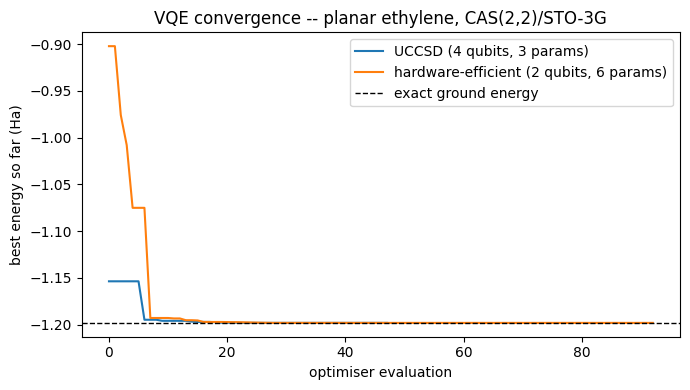

In [ ]:
plt.figure(figsize=(7, 4))
if h_ucc is not None:
    plt.plot(np.minimum.accumulate(h_ucc),
             label=f"UCCSD (4 qubits, {ucc.num_parameters} params)")
plt.plot(np.minimum.accumulate(h_hea),
         label=f"hardware-efficient (2 qubits, {hea.num_parameters} params)")
plt.axhline(E0_exact, color="k", ls="--", lw=1, label="exact ground energy")
plt.xlabel("optimiser evaluation"); plt.ylabel("best energy so far (Ha)")
plt.title("VQE convergence -- planar ethylene, CAS(2,2)/STO-3G")
plt.legend(); plt.tight_layout(); plt.show()

## Section 3 — Excited states via Quantum Subspace Expansion (QSE)

 VQE only gives the ground state |ψ₀⟩. To reach excited
states we act on |ψ₀⟩- in simple words - exploring neighbouring related space in a small subspace around the output to find the least error , using  a few **excitation operators** {Ê_μ} (e.g. "move an
electron from π to π\*"). The states {Ê_μ|ψ₀⟩} span a small subspace. We build
two tiny matrices,

$$\tilde H_{\mu\nu}=\langle\psi_0|\hat E_\mu^\dagger \,H\,\hat E_\nu|\psi_0\rangle,\qquad
   S_{\mu\nu}=\langle\psi_0|\hat E_\mu^\dagger \hat E_\nu|\psi_0\rangle,$$

and solve the small generalised eigenvalue problem $\tilde H\,c = E\,S\,c$. Its
eigenvalues approximate the low-lying energies, so the **first gap is the
π→π\* excitation energy**.

Operator pool (minimal and non-redundant): identity, the spin-adapted π→π\*
single excitation, and the π²→π\*² double excitation — exactly enough to span
the singlet subspace of CAS(2,2).

In [ ]:
r2 = 1.0 / np.sqrt(2.0) #defining excitation operators

#defining two fermionic excitation operators corresponding to each orbital (HOMO-LUMO)
exc_ferm = [
    FermionicOp({"+_1 -_0": r2, "+_3 -_2": r2}, num_spin_orbitals=4),   # single excitation pi -> pi*
    FermionicOp({"+_1 +_3 -_2 -_0": 1.0}, num_spin_orbitals=4),         # double excitation pi^2 -> pi*^2
]

pool_ops = [np.eye(16, dtype=complex)] + [jw.map(o).to_matrix() for o in exc_ferm]

def run_qse(H_matrix, psi0_vec, operators, s_cut=1e-8, n_states=3):
    d = len(operators)
    vecs = [O @ psi0_vec for O in operators]
    S  = np.array([[np.vdot(vecs[i], vecs[j])            for j in range(d)] for i in range(d)])
    Ht = np.array([[np.vdot(vecs[i], H_matrix @ vecs[j]) for j in range(d)] for i in range(d)])
    S, Ht = 0.5 * (S + S.conj().T), 0.5 * (Ht + Ht.conj().T)
    w, U = np.linalg.eigh(S)                     # canonical orthogonalisation
    keep = w > s_cut * w.max()
    X = U[:, keep] / np.sqrt(w[keep])
    return np.sort(np.linalg.eigvalsh(X.conj().T @ Ht @ X).real)[:n_states]

# expand around the UCCSD ground state if we have it, else the exact one
if ucc is not None:
    psi0 = Statevector(ucc.assign_parameters(p_ucc)).data
else:
    psi0 = np.linalg.eigh(H_jw_eq.to_matrix())[1][:, 0]

qse_energies = run_qse(H_jw_eq.to_matrix(), psi0, pool_ops)
pi_pi_star_qse = (qse_energies[1] - qse_energies[0]) * HARTREE2EV

print("QSE energies (Ha):", np.round(qse_energies, 6))
print(f"\nQSE pi->pi* vertical excitation = {pi_pi_star_qse:.3f} eV")
print(f"experimental band maximum      = {EXP_PI_PI_STAR:.1f} eV")
RESULTS["QSE_pi_pi_star_eV"] = float(pi_pi_star_qse)

QSE energies (Ha): [-1.198258 -0.678095 -0.488753]

QSE pi->pi* vertical excitation = 14.154 eV
experimental band maximum      = 7.6 eV


### 3.1  Why is the number so far above 7.6 eV?

CAS(2,2)/STO-3G is the *smallest possible* model. It has

* a **minimal basis** (no room for orbitals to relax or spread out),
* only **2 active orbitals** (no dynamic correlation),
* **no diffuse functions** (the real π→π\* "V" state is partly diffuse).

All three push the excitation energy up, so ~13–15 eV here is *expected*, not a
bug — this is a textbook-hard case. Section 5 shows CASSCF and EOM-CCSD moving
the number toward experiment; a larger basis (e.g. aug-cc-pVDZ) plus a bigger
active space is what finally reaches ~7–8 eV. **We are validating the pipeline;
the absolute value is capped by the cheap model.**

### 3.2  Cross-check: does QSE match exact diagonalisation?

We diagonalise the 4-qubit Hamiltonian exactly and label each state by its
electron number ⟨N⟩, spin projection ⟨S_z⟩, and total spin ⟨S²⟩. We build S²
from the spin-ladder operators $S^2 = S_z^2 + S_z + S_-S_+$ with
$S_+=\sum_i a^\dagger_{i\alpha}a_{i\beta}$ — this is the step the reference
notebook got wrong (it used the wrong operator size and mislabelled every
state).

In [ ]:
N_op  = FermionicOp({f"+_{p} -_{p}": 1.0 for p in range(4)}, num_spin_orbitals=4)
Sz_op = FermionicOp({**{f"+_{p} -_{p}":  0.5 for p in (0, 1)},
                     **{f"+_{p} -_{p}": -0.5 for p in (2, 3)}}, num_spin_orbitals=4)
Sp_op = FermionicOp({"+_0 -_2": 1.0, "+_1 -_3": 1.0}, num_spin_orbitals=4)   # S_+
Sm_op = FermionicOp({"+_2 -_0": 1.0, "+_3 -_1": 1.0}, num_spin_orbitals=4)   # S_-

Nm  = jw.map(N_op ).to_matrix().real
Szm = jw.map(Sz_op).to_matrix().real
Spm = jw.map(Sp_op).to_matrix()
Smm = jw.map(Sm_op).to_matrix()
S2m = (Szm @ Szm + Szm + (Smm @ Spm)).real          # S^2 = Sz^2 + Sz + S- S+

evals, evecs = np.linalg.eigh(H_jw_eq.to_matrix())
print(f"{'#':>2} {'E (Ha)':>12} {'<N>':>6} {'<Sz>':>6} {'<S^2>':>7}  label")
singlet2e = []
for i in range(len(evals)):
    v = evecs[:, i]
    n  = np.vdot(v, Nm  @ v).real
    sz = np.vdot(v, Szm @ v).real
    s2 = np.vdot(v, S2m @ v).real
    if abs(n - 2) < 1e-6 and abs(sz) < 1e-6:
        lab = "singlet" if abs(s2) < 0.3 else ("triplet" if abs(s2 - 2) < 0.3 else "?")
        print(f"{i:>2} {evals[i]:>12.6f} {n:>6.2f} {sz:>6.2f} {s2:>7.3f}  {lab}")
        if lab == "singlet":
            singlet2e.append(evals[i])

gap_exact_eV = (singlet2e[1] - singlet2e[0]) * HARTREE2EV
print(f"\nexact-diag singlet pi->pi* = {gap_exact_eV:.3f} eV")
print(f"QSE   singlet pi->pi*      = {pi_pi_star_qse:.3f} eV")
print(f"difference                 = {abs(gap_exact_eV - pi_pi_star_qse):.2e} eV")
RESULTS["exactdiag_pi_pi_star_eV"] = float(gap_exact_eV)

 #       E (Ha)    <N>   <Sz>   <S^2>  label
 0    -1.198258   2.00   0.00   0.000  singlet
 2    -1.022168   2.00   0.00   2.000  triplet
 8    -0.678095   2.00   0.00   0.000  singlet
13    -0.488753   2.00   0.00   0.000  singlet

exact-diag singlet pi->pi* = 14.154 eV
QSE   singlet pi->pi*      = 14.154 eV
difference                 = 2.42e-07 eV


### 3.3  Twisting the molecule: the π→π\* gap collapses

As we rotate one CH₂ group toward 90° the π bond weakens, the π→π\* gap shrinks,
and the lowest singlet and triplet become **degenerate** — the twisted molecule
is an open-shell *biradical*. This is the heart of the photo-isomerisation
funnel.

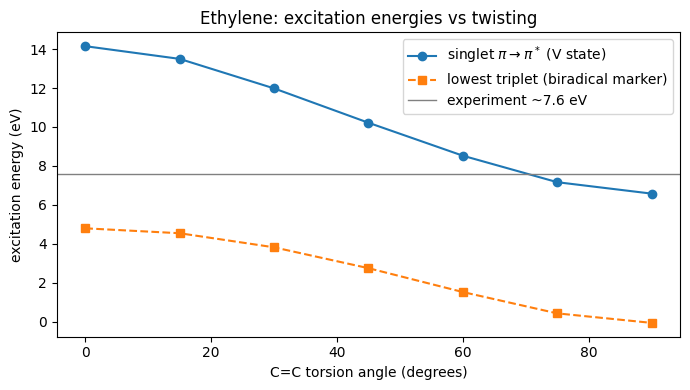

singlet gap 0 deg -> 90 deg : 14.15 eV -> 6.57 eV
triplet gap at 90 deg       : -0.07 eV  (near 0 => biradical)


In [ ]:
angles = list(range(0, 91, 15))
gap_singlet, gap_triplet = [], []
for a in angles:
    _, cas_a, _ = build_problem(a, verbose=False)
    Hm = jw.map(cas_a.hamiltonian.second_q_op()).to_matrix()
    ev, vc = np.linalg.eigh(Hm)
    s_list, t_list = [], []
    for i in range(len(ev)):
        v = vc[:, i]
        if abs(np.vdot(v, Nm @ v).real - 2) > 1e-6 or abs(np.vdot(v, Szm @ v).real) > 1e-6:
            continue
        s2 = np.vdot(v, S2m @ v).real
        (s_list if abs(s2) < 0.3 else t_list).append(ev[i])
    e0 = min(s_list)
    gap_singlet.append((sorted(s_list)[1] - e0) * HARTREE2EV)
    gap_triplet.append((min(t_list) - e0) * HARTREE2EV if t_list else np.nan)

plt.figure(figsize=(7, 4))
plt.plot(angles, gap_singlet, "o-", label=r"singlet $\pi\to\pi^*$ (V state)")
plt.plot(angles, gap_triplet, "s--", label="lowest triplet (biradical marker)")
plt.axhline(EXP_PI_PI_STAR, color="grey", lw=1, label="experiment ~7.6 eV")
plt.xlabel("C=C torsion angle (degrees)"); plt.ylabel("excitation energy (eV)")
plt.title("Ethylene: excitation energies vs twisting")
plt.legend(); plt.tight_layout(); plt.show()

print("singlet gap 0 deg -> 90 deg :", round(gap_singlet[0], 2), "eV ->", round(gap_singlet[-1], 2), "eV")
print("triplet gap at 90 deg       :", round(gap_triplet[-1], 3), "eV  (near 0 => biradical)")

## Section 4 — Noise-aware benchmarking  *(Core Task 4)*

Real devices make two kinds of error we model here:

* **gate noise** — after every gate the state is slightly randomised
  (*depolarising* error): ~0.1 % per 1-qubit gate, ~1 % per 2-qubit gate.
* **readout error** — a qubit that is really `0` is reported as `1` a few
  percent of the time (and vice-versa).

We run the optimised **2-qubit** hardware-efficient circuit on a noisy Aer
simulator, then apply two standard fixes — each targets a *different* error
source:

1. **Readout mitigation** (fixes *measurement* errors) — measure the 4×4
   "confusion matrix" and invert it.
2. **Zero-noise extrapolation, ZNE** (fixes *gate* errors) — run the circuit at
   noise levels 1×, 2×, 3× and extrapolate the energy back to **0×**. Here we
   scale the simulator's error rates directly; on real hardware you would scale
   the noise by *gate folding* instead, but the extrapolation step is identical.

In [ ]:
P1, P2, P_RO = 2e-3, 2e-2, 2e-2                 # 1q depol, 2q depol, readout error

def make_noise_model(p1=P1, p2=P2, p_ro=P_RO):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1),
                                   ["u", "ry", "rz", "rx", "sx", "x", "h"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx", "cz"])
    nm.add_all_qubit_readout_error(ReadoutError([[1 - p_ro, p_ro], [p_ro, 1 - p_ro]]))
    return nm

NOISE = make_noise_model()
sim_shots = AerSimulator(noise_model=NOISE)
hea_opt = hea.assign_parameters(p_hea)          # 2-qubit state-prep at the VQE optimum

def energy_from_shots(state_circ, H, sim, shots=100000, A_inv=None):
    n = state_circ.num_qubits
    total = 0.0
    for label, coeff in zip(H.paulis.to_labels(), H.coeffs.real):
        if set(label) == {"I"}:
            total += coeff
            continue
        qc = state_circ.copy()
        for q, p in enumerate(reversed(label)):
            if p == "X": qc.h(q)
            elif p == "Y": qc.sdg(q); qc.h(q)
        qc.measure_all()
        counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
        probs = np.zeros(2 ** n)
        for b, c in counts.items():
            probs[int(b, 2)] += c / shots
        if A_inv is not None:
            probs = np.clip(A_inv @ probs, 0, None); probs /= probs.sum()
        exp = 0.0
        for idx, pr in enumerate(probs):
            par = sum(((idx >> q) & 1) for q, p in enumerate(reversed(label)) if p != "I") % 2
            exp += pr * (1 if par == 0 else -1)
        total += coeff * exp
    return total

def calibration_matrix(n, sim, shots=100000):
    A = np.zeros((2 ** n, 2 ** n))
    for prep in range(2 ** n):
        qc = QuantumCircuit(n)
        for q in range(n):
            if (prep >> q) & 1:
                qc.x(q)
        qc.measure_all()
        counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
        for b, c in counts.items():
            A[int(b, 2), prep] += c / shots
    return A

A = calibration_matrix(H_par_eq.num_qubits, sim_shots)
A_inv = np.linalg.inv(A)
print("readout confusion matrix A (rows = measured, cols = prepared):")
print(np.round(A, 3))

readout confusion matrix A (rows = measured, cols = prepared):
[[0.961 0.021 0.021 0.001]
 [0.019 0.959 0.    0.02 ]
 [0.02  0.    0.959 0.02 ]
 [0.    0.02  0.019 0.959]]


exact ground energy (2 qubits)         = -1.19826 Ha
noisy, raw (shots)                     = -1.16561 Ha   err   32.6 mHa
noisy, + readout mitigation (shots)    = -1.18337 Ha   err   14.9 mHa
noisy, + ZNE (gate errors, linear fit) = -1.19738 Ha   err    0.9 mHa


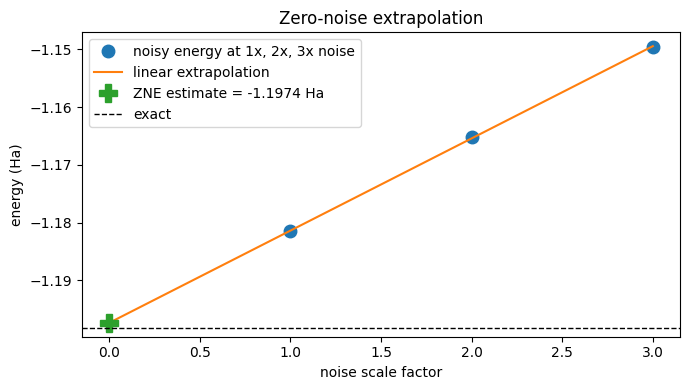

In [ ]:
def dm_energy(circ, H, noise_model):
    '''Exact (no sampling) noisy <H> via the density-matrix simulator.'''
    sim = AerSimulator(method="density_matrix", noise_model=noise_model)
    c = circ.copy(); c.save_density_matrix()
    rho = DensityMatrix(sim.run(transpile(c, sim)).result().data()["density_matrix"])
    return float(np.real(rho.expectation_value(H)))

# ---- ZNE: scale the depolarising rates by 1x, 2x, 3x and extrapolate to 0x ----
scales = [1.0, 2.0, 3.0]
E_scaled = [dm_energy(hea_opt, H_par_eq, make_noise_model(P1 * s, P2 * s, P_RO))
            for s in scales]
zne_fit = np.polyfit(scales, E_scaled, 1)
E_zne = float(np.polyval(zne_fit, 0.0))

# ---- shot-based numbers for the readout-mitigation demonstration ----
E_exact2  = E0_exact_par
E_raw     = energy_from_shots(hea_opt, H_par_eq, sim_shots)
E_readout = energy_from_shots(hea_opt, H_par_eq, sim_shots, A_inv=A_inv)

print(f"exact ground energy (2 qubits)         = {E_exact2:.5f} Ha")
print(f"noisy, raw (shots)                     = {E_raw:.5f} Ha   err {abs(E_raw-E_exact2)*1000:6.1f} mHa")
print(f"noisy, + readout mitigation (shots)    = {E_readout:.5f} Ha   err {abs(E_readout-E_exact2)*1000:6.1f} mHa")
print(f"noisy, + ZNE (gate errors, linear fit) = {E_zne:.5f} Ha   err {abs(E_zne-E_exact2)*1000:6.1f} mHa")
RESULTS["noisy_E0_err_raw_mHa"] = float(abs(E_scaled[0] - E_exact2) * 1000)
RESULTS["noisy_E0_err_zne_mHa"] = float(abs(E_zne - E_exact2) * 1000)

plt.figure(figsize=(7, 4))
plt.plot(scales, E_scaled, "o", ms=9, label="noisy energy at 1x, 2x, 3x noise")
xs = np.linspace(0, 3, 50)
plt.plot(xs, np.polyval(zne_fit, xs), "-", label="linear extrapolation")
plt.plot(0, E_zne, "P", ms=13, label=f"ZNE estimate = {E_zne:.4f} Ha")
plt.axhline(E_exact2, color="k", ls="--", lw=1, label="exact")
plt.xlabel("noise scale factor"); plt.ylabel("energy (Ha)")
plt.title("Zero-noise extrapolation"); plt.legend(); plt.tight_layout(); plt.show()

### 4.1  Effect of noise on the *excitation* energy

We also check the QSE π→π\* gap under noise. We get the noisy ground state as a
**density matrix** ρ and rebuild the QSE matrices from it. Excitation energies
are more fragile than the ground energy because they are a *difference* of two
noisy numbers.

In [ ]:
sim_dm = AerSimulator(method="density_matrix", noise_model=NOISE)
circ_dm = hea_opt.copy(); circ_dm.save_density_matrix()
rho = DensityMatrix(sim_dm.run(transpile(circ_dm, sim_dm)).result().data()["density_matrix"])

I2 = Operator(np.eye(2 ** H_par_eq.num_qubits, dtype=complex))
pool_par = [I2] + [Operator(par.map(o).to_matrix()) for o in exc_ferm]
H2_op = Operator(H_par_eq.to_matrix())

d = len(pool_par)
S  = np.zeros((d, d), complex); Ht = np.zeros((d, d), complex)
for i in range(d):
    for j in range(d):
        S[i, j]  = rho.expectation_value(pool_par[i].adjoint() @ pool_par[j])
        Ht[i, j] = rho.expectation_value(pool_par[i].adjoint() @ H2_op @ pool_par[j])
S, Ht = 0.5 * (S + S.conj().T), 0.5 * (Ht + Ht.conj().T)
w, U = np.linalg.eigh(S); keep = w > 1e-6 * w.max()
X = U[:, keep] / np.sqrt(w[keep])
ev = np.sort(np.linalg.eigvalsh(X.conj().T @ Ht @ X).real)
pi_pi_star_noisy = (ev[1] - ev[0]) * HARTREE2EV

print(f"pi->pi* gap, noiseless QSE = {pi_pi_star_qse:.3f} eV")
print(f"pi->pi* gap, noisy QSE     = {pi_pi_star_noisy:.3f} eV")
print(f"shift due to noise         = {pi_pi_star_noisy - pi_pi_star_qse:+.3f} eV")
RESULTS["noisy_pi_pi_star_eV"] = float(pi_pi_star_noisy)

pi->pi* gap, noiseless QSE = 14.154 eV
pi->pi* gap, noisy QSE     = 13.755 eV
shift due to noise         = -0.400 eV


## Section 5 — Classical benchmarking  *(Core Task 5)*

We compare the quantum pipeline against standard classical methods:

* **exact diagonalisation** of the CAS(2,2) qubit Hamiltonian = **CASCI(2,2)**
  (what VQE+QSE should reproduce),
* **CASSCF(2,2)** — same active space, orbitals re-optimised,
* **EOM-CCSD** — a high-quality single-reference method on the *full* molecule.

In [ ]:
from pyscf import gto, scf, mcscf

mol = gto.M(atom="; ".join(ethylene_geometry(0)), basis="sto3g", verbose=0)
mf = scf.RHF(mol).run()
print(f"RHF/STO-3G total energy = {mf.e_tot:.8f} Ha")

mc = mcscf.CASCI(mf, 2, 2)
mc.fcisolver.nroots = 3
mc.kernel()
casci = np.atleast_1d(mc.e_tot)
casci_gap = (casci[1] - casci[0]) * HARTREE2EV
print(f"\nCASCI(2,2) roots (Ha): {np.round(casci, 6)}")
print(f"CASCI(2,2) first excitation = {casci_gap:.3f} eV")

try:
    mcs = mcscf.CASSCF(mf, 2, 2)
    mcs.state_average_([1 / 3, 1 / 3, 1 / 3])
    mcs.kernel()
    casscf = np.atleast_1d(mcs.e_states)
    casscf_gap = (casscf[1] - casscf[0]) * HARTREE2EV
    print(f"\nCASSCF(2,2) roots (Ha): {np.round(casscf, 6)}")
    print(f"CASSCF(2,2) first excitation = {casscf_gap:.3f} eV")
except Exception as exc:
    casscf_gap = float("nan")
    print("CASSCF skipped:", repr(exc))

try:
    from pyscf import cc
    mycc = cc.CCSD(mf).run()
    e_ee, _ = mycc.eomee_ccsd_singlet(nroots=1)
    eom_gap = float(np.atleast_1d(e_ee)[0]) * HARTREE2EV
    print(f"\nEOM-CCSD (full molecule) first singlet excitation = {eom_gap:.3f} eV")
except Exception as exc:
    eom_gap = float("nan")
    print("EOM-CCSD skipped:", repr(exc))

RESULTS["CASCI_pi_pi_star_eV"] = float(casci_gap)
RESULTS["CASSCF_pi_pi_star_eV"] = float(casscf_gap)
RESULTS["EOMCCSD_pi_pi_star_eV"] = float(eom_gap)

RHF/STO-3G total energy = -77.07212304 Ha

CASCI(2,2) roots (Ha): [-77.116629 -76.940539 -76.596467]
CASCI(2,2) first excitation = 4.792 eV

CASSCF(2,2) roots (Ha): [-77.116512 -76.940868 -76.596795]
CASSCF(2,2) first excitation = 4.780 eV

EOM-CCSD (full molecule) first singlet excitation = 12.923 eV


In [ ]:
# --- OpenFermion cross-check of the active-space ground energy -------
try:
    from openfermion import MolecularData, jordan_wigner as of_jw, get_sparse_operator
    from openfermion.linalg import get_ground_state
    from openfermionpyscf import run_pyscf

    geo = [(a.split()[0], tuple(map(float, a.split()[1:]))) for a in ethylene_geometry(0)]
    of_mol = run_pyscf(MolecularData(geo, "sto-3g", 1, 0), run_scf=True)
    nocc = of_mol.n_electrons // 2
    ham = of_mol.get_molecular_hamiltonian(occupied_indices=list(range(nocc - 1)),
                                           active_indices=[nocc - 1, nocc])
    e_of = get_ground_state(get_sparse_operator(of_jw(ham)))[0]
    print(f"OpenFermion active-space ground energy = {e_of:.8f} Ha")
    print("(Different constant offset from Qiskit's; the *excitation gaps* are the real check.)")
except Exception as exc:
    print("OpenFermion cross-check skipped:", repr(exc))

OpenFermion active-space ground energy = -77.11662916 Ha
(Different constant offset from Qiskit's; the *excitation gaps* are the real check.)


In [ ]:
rows = [
    ("experiment",              EXP_PI_PI_STAR),
    ("VQE + QSE (this work)",    RESULTS.get("QSE_pi_pi_star_eV")),
    ("exact diag = CASCI(2,2)", RESULTS.get("exactdiag_pi_pi_star_eV")),
    ("CASSCF(2,2)",             RESULTS.get("CASSCF_pi_pi_star_eV")),
    ("EOM-CCSD (full molecule)", RESULTS.get("EOMCCSD_pi_pi_star_eV")),
]
print(f"{'method':<26}{'pi->pi* (eV)':>14}")
print("-" * 40)
for name, gap in rows:
    print(f"{name:<26}{gap:>14.3f}")

method                      pi->pi* (eV)
----------------------------------------
experiment                         7.600
VQE + QSE (this work)             14.154
exact diag = CASCI(2,2)           14.154
CASSCF(2,2)                        4.780
EOM-CCSD (full molecule)          12.923


## Section 6 — Extension  *(Core Task 6)*

Turning a π→π\* excitation into an electron-transfer rate: the QSE energies feed
the electronic coupling `H_DA` and driving force `dG`; a classical relaxation
gives the reorganisation energy `lambda`; Marcus theory gives the rate.

```
 embedded donor-acceptor fragment  ->  active-space Hamiltonian   (same object as Section 1)
   |  Jordan-Wigner + tapering  ->  qubit Hamiltonian
   v
 VQE ground state  ->  QSE excited states
   |    |- diabatise the two lowest states       -> electronic coupling  H_DA
   |    |- QSE energies at shifted geometries    -> driving force  dG
   v
 k_ET = (2*pi/hbar) |H_DA|^2 (4*pi*lambda*kT)^(-1/2) exp[ -(dG+lambda)^2 / (4*lambda*kT) ]
   v
 photocurrent  j = e * flux * k_ET / (k_ET + k_loss)
```

Two runnable pieces below: **(1)** the pipeline on a larger molecule —
butadiene, CAS(4,4), 8 qubits — and **(2)** the Marcus-rate step with a plot.

In [ ]:
# --- (1) butadiene CAS(4,4)/STO-3G : the pipeline on 8 qubits --------
def butadiene_geometry():
    return [                                   # planar s-trans 1,3-butadiene (Angstrom)
        "C  -1.833  -0.219  0.000", "C  -0.611   0.325  0.000",
        "C   0.611  -0.325  0.000", "C   1.833   0.219  0.000",
        "H  -2.716   0.406  0.000", "H  -1.944  -1.298  0.000",
        "H  -0.520   1.406  0.000", "H   0.520  -1.406  0.000",
        "H   2.716  -0.406  0.000", "H   1.944   1.298  0.000",
    ]

drv = PySCFDriver(atom=butadiene_geometry(), basis="sto3g", unit=DistanceUnit.ANGSTROM)
bd_full = drv.run()
nocc = bd_full.num_particles[0]
bd_cas = ActiveSpaceTransformer(
    4, 4, active_orbitals=[nocc - 2, nocc - 1, nocc, nocc + 1]).transform(bd_full)
H_bd = jw.map(bd_cas.hamiltonian.second_q_op())
ev_bd = np.linalg.eigvalsh(H_bd.to_matrix())
gap_bd = next(((e - ev_bd[0]) * HARTREE2EV for e in ev_bd[1:] if e - ev_bd[0] > 1e-4), None)
print(f"butadiene CAS(4,4)/STO-3G -> {H_bd.num_qubits} qubits")
print(f"lowest exact excitation   = {gap_bd:.2f} eV   (experiment ~5.9 eV)")

try:
    hf_bd = HartreeFock(4, bd_cas.num_particles, jw)
    ucc_bd = UCCSD(4, bd_cas.num_particles, jw, initial_state=hf_bd)
    _, e_bd, _ = run_vqe(H_bd, ucc_bd, np.zeros(ucc_bd.num_parameters),
                         method="COBYLA", maxiter=300)
    print(f"VQE/UCCSD ground energy   = {e_bd:.6f} Ha  "
          f"(exact {ev_bd[0]:.6f} Ha, error {abs(e_bd - ev_bd[0]) * 1000:.2f} mHa)")
except Exception as exc:
    print("butadiene VQE skipped:", repr(exc))

butadiene CAS(4,4)/STO-3G -> 8 qubits
lowest exact excitation   = 3.38 eV   (experiment ~5.9 eV)
VQE/UCCSD ground energy   = -3.317185 Ha  (exact -3.317665 Ha, error 0.48 mHa)


at dG = -0.3 eV :  k_ET = 9.834e+12 1/s   (tau = 0.1 ps)
transfer yield = 0.9999   ->   photocurrent j = 1.602e-11 A per site


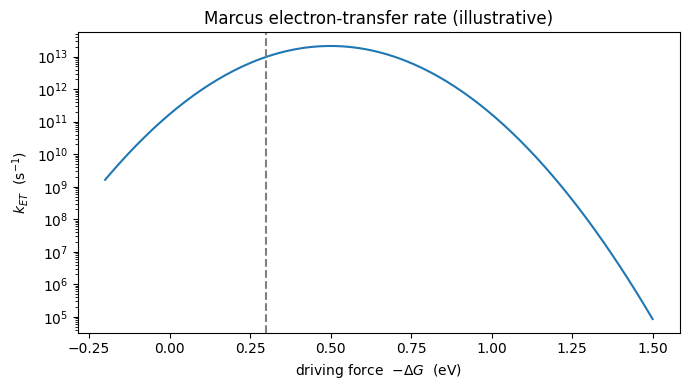

In [ ]:
# --- (2) Marcus electron-transfer rate (illustrative numbers) -------
KB_EV, HBAR_EV_S, E_CHG = 8.617333e-5, 6.582119e-16, 1.602177e-19

def marcus_rate(H_DA, dG, lam, T=300.0):
    pref = (2 * np.pi / HBAR_EV_S) * H_DA ** 2
    fc = 1.0 / np.sqrt(4 * np.pi * lam * KB_EV * T)
    return pref * fc * np.exp(-((dG + lam) ** 2) / (4 * lam * KB_EV * T))

H_DA, lam, T = 0.03, 0.50, 300.0            # eV, eV, K   (H_DA & dG would come from QSE)
dG_scan = np.linspace(-1.5, 0.2, 200)
k_scan = np.array([marcus_rate(H_DA, dG, lam, T) for dG in dG_scan])

dG0 = -0.30
k0 = marcus_rate(H_DA, dG0, lam, T)
k_loss, flux = 1e9, 1e8
yield_ = k0 / (k0 + k_loss)
j = E_CHG * flux * yield_
print(f"at dG = {dG0} eV :  k_ET = {k0:.3e} 1/s   (tau = {1 / k0 * 1e12:.1f} ps)")
print(f"transfer yield = {yield_:.4f}   ->   photocurrent j = {j:.3e} A per site")

plt.figure(figsize=(7, 4))
plt.semilogy(-dG_scan, k_scan)
plt.axvline(-dG0, color="grey", ls="--")
plt.xlabel(r"driving force  $-\Delta G$  (eV)"); plt.ylabel(r"$k_{ET}$  (s$^{-1}$)")
plt.title("Marcus electron-transfer rate (illustrative)")
plt.tight_layout(); plt.show()

## Section 7 — Headline numbers from this run

In [ ]:
print("=" * 60)
print("HEADLINE NUMBERS FROM THIS RUN")
print("=" * 60)
for k, v in RESULTS.items():
    print(f"  {k:<28} = {v}")

HEADLINE NUMBERS FROM THIS RUN
  E0_exact_active_Ha           = -1.1982580454948561
  VQE_UCCSD_err_mHa            = 9.839399739419719e-06
  UCCSD_params                 = 3
  VQE_HEA_err_mHa              = 7.987188688218794e-08
  HEA_params                   = 6
  QSE_pi_pi_star_eV            = 14.154346772088088
  exactdiag_pi_pi_star_eV      = 14.154347014396548
  noisy_E0_err_raw_mHa         = 16.762037838458532
  noisy_E0_err_zne_mHa         = 0.8751469207941565
  noisy_pi_pi_star_eV          = 13.754789943313577
  CASCI_pi_pi_star_eV          = 4.791650113007574
  CASSCF_pi_pi_star_eV         = 4.779533969149338
  EOMCCSD_pi_pi_star_eV        = 12.922503285329235
